# SVM Pipeline Comparison: With and Without SMOTE

This notebook runs an SVM classification pipeline on the Bank Marketing dataset in two ways:

1. **Without SMOTE:** The pipeline trains an SVM model on the original (scaled) training data.
2. **With SMOTE:** SMOTE is applied to the scaled training set to balance the class distribution before training the SVM model.

After both runs, the notebook prints evaluation metrics (accuracy, confusion matrix, classification report, ROC curve and AUC) so that you can compare which approach works better.

In [12]:
import pandas as pd
import numpy as np
import os
import json
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc

from imblearn.over_sampling import SMOTE

# Create directories if they don't exist
def create_directories():
    dirs = ['results/metrics', 'results/plots', 'results/models']
    for dir_path in dirs:
        os.makedirs(dir_path, exist_ok=True)

create_directories()

### Preprocessing and Scaling Functions

The function **preprocess_data** loads the training (`bank.csv`) and test (`bank-full.csv`) datasets, performs label encoding on a fixed list of categorical variables, maps the target variable (`y`) from 'yes'/'no' to 1/0, and then splits the combined data back into training and test sets.

The **scale_features** function applies standard scaling to the features.

In [13]:
def preprocess_data(train_path, test_path):
    # Load datasets using ';' as the delimiter
    train_data = pd.read_csv(train_path, sep=';')
    test_data = pd.read_csv(test_path, sep=';')
    
    # Combine for consistent encoding
    all_data = pd.concat([train_data, test_data], axis=0)
    
    categorical_columns = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
    encoder = LabelEncoder()
    for col in categorical_columns:
        all_data[col] = encoder.fit_transform(all_data[col])
    
    # Map target variable
    all_data['y'] = all_data['y'].map({'yes': 1, 'no': 0})
    
    n_train = train_data.shape[0]
    train_data = all_data.iloc[:n_train, :]
    test_data = all_data.iloc[n_train:, :]
    
    X_train = train_data.drop(columns=['y'])
    y_train = train_data['y']
    X_test = test_data.drop(columns=['y'])
    y_test = test_data['y']
    
    return X_train, X_test, y_train, y_test

def scale_features(X_train, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled, scaler

### SVM Training and Evaluation Function

The following function, **run_pipeline**, encapsulates the SVM pipeline. It accepts one parameter, `use_smote`, which if set to `True` applies SMOTE to the scaled training data before training the model.

It then trains an SVM (RBF kernel with C=1.0), evaluates the model on the test set and returns evaluation metrics.

In [14]:
def run_pipeline(use_smote_flag):
    # File paths (update if necessary)
    train_path = r'C:\Users\frogo\Desktop\Classification-algorithms-comparison\dataset\archive\bank.csv'
    test_path  = r'C:\Users\frogo\Desktop\Classification-algorithms-comparison\dataset\archive\bank-full.csv'
    
    # Preprocess the data
    X_train, X_test, y_train, y_test = preprocess_data(train_path, test_path)
    print("Training data shape:", X_train.shape)
    print("Testing data shape:", X_test.shape)
    
    # Scale features (SVMs are sensitive to feature scales)
    X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test)
    
    # For this pipeline, we will use the scaled data
    dt_input_train, dt_input_test = X_train_scaled, X_test_scaled
    
    # Apply SMOTE if desired
    if use_smote_flag:
        smote = SMOTE(random_state=42)
        dt_input_train, y_train = smote.fit_resample(dt_input_train, y_train)
        print("After SMOTE, training shape:", dt_input_train.shape)
    
    # Train the SVM model (using RBF kernel)
    svm_model = SVC(kernel='rbf', random_state=42, C=1.0)
    svm_model.fit(dt_input_train, y_train)
    
    # Evaluate on the test set
    y_pred = svm_model.predict(dt_input_test)
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    
    print("\n--- Evaluation ---")
    print("Accuracy:", acc)
    print("Confusion Matrix:")
    print(cm)
    print("\nClassification Report:\n", report)
    
    # ROC Curve and AUC (using decision_function for SVM)
    y_scores = svm_model.decision_function(dt_input_test)
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, label='ROC curve (AUC = %0.2f)' % roc_auc)
    plt.plot([0,1], [0,1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.show()
    
    # Plot confusion matrix
    plt.figure(figsize=(8,6))
    plt.imshow(cm, cmap='Blues', interpolation='nearest')
    plt.title("SVM Confusion Matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.colorbar()
    plt.xticks([0, 1], ['No', 'Yes'])
    plt.yticks([0, 1], ['No', 'Yes'])
    plt.show()
    
    metrics = {
        "accuracy": acc,
        "confusion_matrix": cm.tolist(),
        "classification_report": classification_report(y_test, y_pred, output_dict=True),
        "roc_auc": roc_auc
    }
    return metrics, svm_model, scaler

### Running the Pipeline Without SMOTE

The following cell runs the SVM pipeline without applying SMOTE.

Training data shape: (4521, 16)
Testing data shape: (45211, 16)

--- Evaluation ---
Accuracy: 0.8946937692154564
Confusion Matrix:
[[39475   447]
 [ 4314   975]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.99      0.94     39922
           1       0.69      0.18      0.29      5289

    accuracy                           0.89     45211
   macro avg       0.79      0.59      0.62     45211
weighted avg       0.88      0.89      0.87     45211



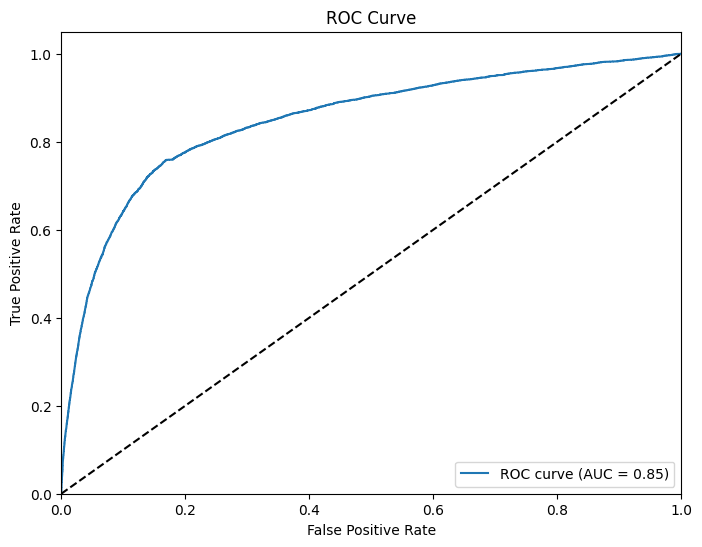

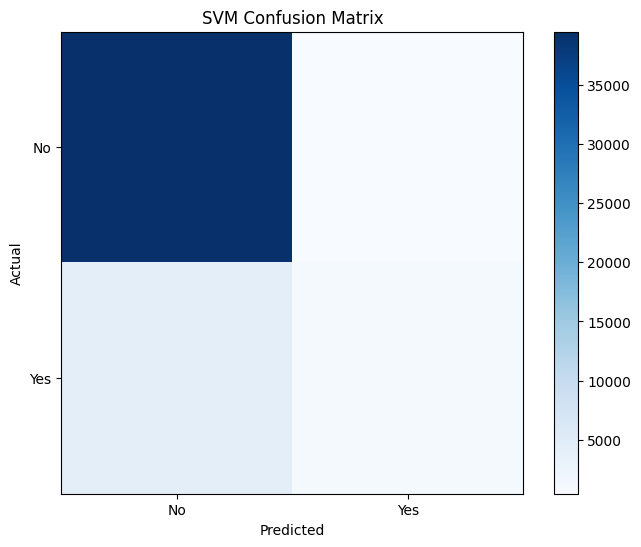


Results Without SMOTE:
{'accuracy': 0.8946937692154564, 'confusion_matrix': [[39475, 447], [4314, 975]], 'classification_report': {'0': {'precision': 0.9014821073785654, 'recall': 0.9888031661740394, 'f1-score': 0.9431257540824981, 'support': 39922.0}, '1': {'precision': 0.6856540084388185, 'recall': 0.184344866704481, 'f1-score': 0.2905677246312025, 'support': 5289.0}, 'accuracy': 0.8946937692154564, 'macro avg': {'precision': 0.7935680579086919, 'recall': 0.5865740164392602, 'f1-score': 0.6168467393568503, 'support': 45211.0}, 'weighted avg': {'precision': 0.8762334994005881, 'recall': 0.8946937692154564, 'f1-score': 0.8667863805280998, 'support': 45211.0}}, 'roc_auc': np.float64(0.8490949249315614)}


In [15]:
metrics_no_smote, model_no_smote, scaler_no_smote = run_pipeline(use_smote_flag=False)
print("\nResults Without SMOTE:")
print(metrics_no_smote)

### Running the Pipeline With SMOTE

Now, the following cell runs the SVM pipeline with SMOTE applied to the training data.

Training data shape: (4521, 16)
Testing data shape: (45211, 16)
After SMOTE, training shape: (8000, 16)

--- Evaluation ---
Accuracy: 0.8399504545354006
Confusion Matrix:
[[34168  5754]
 [ 1482  3807]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.86      0.90     39922
           1       0.40      0.72      0.51      5289

    accuracy                           0.84     45211
   macro avg       0.68      0.79      0.71     45211
weighted avg       0.89      0.84      0.86     45211



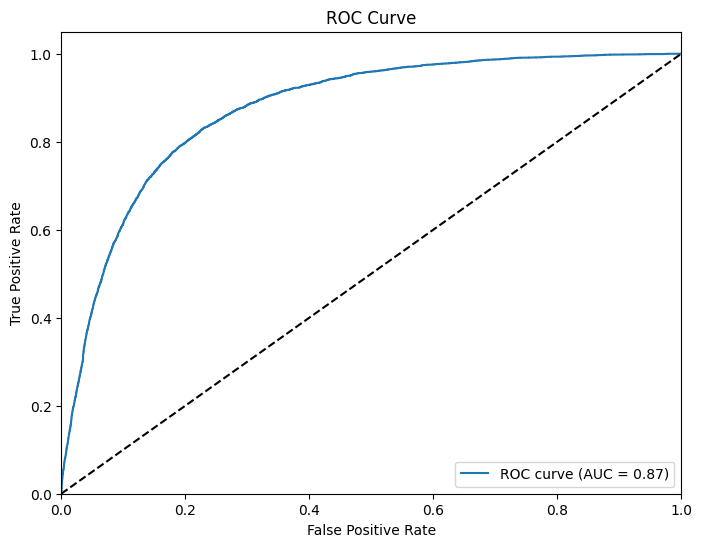

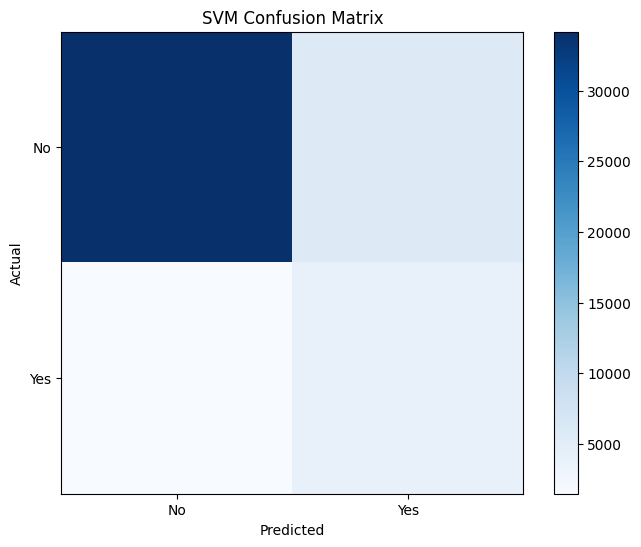


Results With SMOTE:
{'accuracy': 0.8399504545354006, 'confusion_matrix': [[34168, 5754], [1482, 3807]], 'classification_report': {'0': {'precision': 0.958429172510519, 'recall': 0.8558689444416613, 'f1-score': 0.9042502514158683, 'support': 39922.0}, '1': {'precision': 0.3981801066834013, 'recall': 0.7197958026091889, 'f1-score': 0.5127272727272727, 'support': 5289.0}, 'accuracy': 0.8399504545354006, 'macro avg': {'precision': 0.6783046395969601, 'recall': 0.7878323735254251, 'f1-score': 0.7084887620715705, 'support': 45211.0}, 'weighted avg': {'precision': 0.8928885450269501, 'recall': 0.8399504545354006, 'f1-score': 0.8584480122642464, 'support': 45211.0}}, 'roc_auc': np.float64(0.8736823225217328)}


In [16]:
metrics_with_smote, model_with_smote, scaler_with_smote = run_pipeline(use_smote_flag=True)
print("\nResults With SMOTE:")
print(metrics_with_smote)

### Comparison of Results

Below is a summary of the accuracies and ROC-AUC values for the runs with and without SMOTE. Use these metrics to compare which approach works better on the test dataset.

In [19]:
print("Accuracy without SMOTE:", metrics_no_smote["accuracy"])
print("ROC-AUC without SMOTE:", metrics_no_smote["roc_auc"])

print("\nAccuracy with SMOTE:", metrics_with_smote["accuracy"])
print("ROC-AUC with SMOTE:", metrics_with_smote["roc_auc"])

Accuracy without SMOTE: 0.8946937692154564
ROC-AUC without SMOTE: 0.8490949249315614

Accuracy with SMOTE: 0.8399504545354006
ROC-AUC with SMOTE: 0.8736823225217328


Based on the evaluation metrics you provided, here’s one way to interpret and conclude the results:

### Without SMOTE:

Accuracy: Approximately 89.47%

ROC-AUC: Approximately 0.8491

The high accuracy indicates that overall, the SVM model is correctly predicting a large proportion of examples. However, in imbalanced datasets (like this one), high accuracy can sometimes be misleading since the model might be mostly predicting the majority class correctly while missing many minority class instances. The ROC-AUC of 0.8491 shows that the model has a decent ability to differentiate between classes, but there might still be room for improvement in recognizing the minority class.

### With SMOTE:

Accuracy: Approximately 83.99%

ROC-AUC: Approximately 0.8737

When SMOTE is applied, the overall accuracy drops. This drop often occurs because the artificially balanced training data forces the model to pay more attention to the minority class—which can reduce accuracy on the majority class. However, the ROC-AUC increases to 0.8737, indicating that the model's ability to discriminate between the two classes has improved. This suggests that although the overall percentage of correct classifications decreased, the model might be doing a better job at recognizing the minority class.